In [ ]:
import numpy as np
import pandas as pd

# EDA Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_json('/content/modcloth_final_data.json', lines=True)
df.head()

,item_id,waist,size,quality,cup size,hips,bra size,category,bust,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text
0,123373,29.0,7,5.0,d,38.0,34.0,new,36,5ft 6in,Emily,just right,small,991571,NaN,NaN,NaN,NaN
1,123373,31.0,13,3.0,b,30.0,36.0,new,NaN,5ft 2in,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,NaN
2,123373,30.0,7,2.0,b,NaN,32.0,new,NaN,5ft 7in,Ugggh,slightly long,small,395665,9.0,NaN,NaN,NaN
3,123373,NaN,21,5.0,dd/e,NaN,NaN,new,NaN,NaN,alexmeyer626,just right,fit,875643,NaN,NaN,NaN,NaN
4,123373,NaN,18,5.0,b,NaN,36.0,new,NaN,5ft 2in,dberrones1,slightly long,small,944840,NaN,NaN,NaN,NaN


In [ ]:
df.columns = ['item_id', 'waist', 'mc_size', 'quality', 'cup_size', 'hips', 'bra_size', 'category', 'bust', 'height', 'user_name', 'length', 'fit', 'user_id', 'shoe_size', 'shoe_width', 'review_summary', 'review_test']

In [ ]:
df.info()

In [ ]:
missing_data_sum = df.isnull().sum()
missing_data = pd.DataFrame({'total_missing_values': missing_data_sum,'percentage_of_missing_values': (missing_data_sum/df.shape[0])*100})
missing_data

In [ ]:
df.dtypes

In [ ]:
df.nunique()

In [ ]:
def countplot(indipendent_features):
  plt.figure(figsize=(25, 25))
  for loc, feature in enumerate(indipendent_features):
    ax = plt.subplot(3, 4, loc+1)
    ax.set_xlabel('{}'.format(feature), fontsize=10)
    chart = sns.countplot(df[feature])
    chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
  return None

In [ ]:
#uniques_data = ['quality', 'cup_size', 'bra_size', 'category', 'length', 'fit',  'shoe_size', 'shoe_width', 'height', 'bust', 'mc_size']
#countplot(uniques_data)

In [ ]:
# replacing bust unformatted value with mean 38 which is taken from the values 37 & 39
df.at[df[df.bust == '37-39'].index[0],'bust'] = '38'

In [ ]:
def height_in_cms(ht):
  if ht.lower() != 'nan':
    ht = ht.replace('ft','').replace('in', '')
    h_ft = int(ht.split()[0])
    if len(ht.split()) > 1:
      h_inch = int(ht.split()[1])
    else:
      h_inch = 0
    h_inch += h_ft * 12
    h_cm = round(h_inch * 2.54, 1)
    return h_cm

df.height = df.height.astype(str).apply(height_in_cms)
df.head()

,item_id,waist,mc_size,quality,cup_size,hips,bra_size,category,bust,height,user_name,length,fit,user_id,shoe_size,shoe_width,review_summary,review_test
0,123373,29.0,7,5.0,d,38.0,34.0,new,36,167.6,Emily,just right,small,991571,NaN,NaN,NaN,NaN
1,123373,31.0,13,3.0,b,30.0,36.0,new,NaN,157.5,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,NaN
2,123373,30.0,7,2.0,b,NaN,32.0,new,NaN,170.2,Ugggh,slightly long,small,395665,9.0,NaN,NaN,NaN
3,123373,NaN,21,5.0,dd/e,NaN,NaN,new,NaN,NaN,alexmeyer626,just right,fit,875643,NaN,NaN,NaN,NaN
4,123373,NaN,18,5.0,b,NaN,36.0,new,NaN,157.5,dberrones1,slightly long,small,944840,NaN,NaN,NaN,NaN


In [ ]:
df.height.fillna(value=df.height.mean(), inplace=True)
df.height.isnull().sum()

0

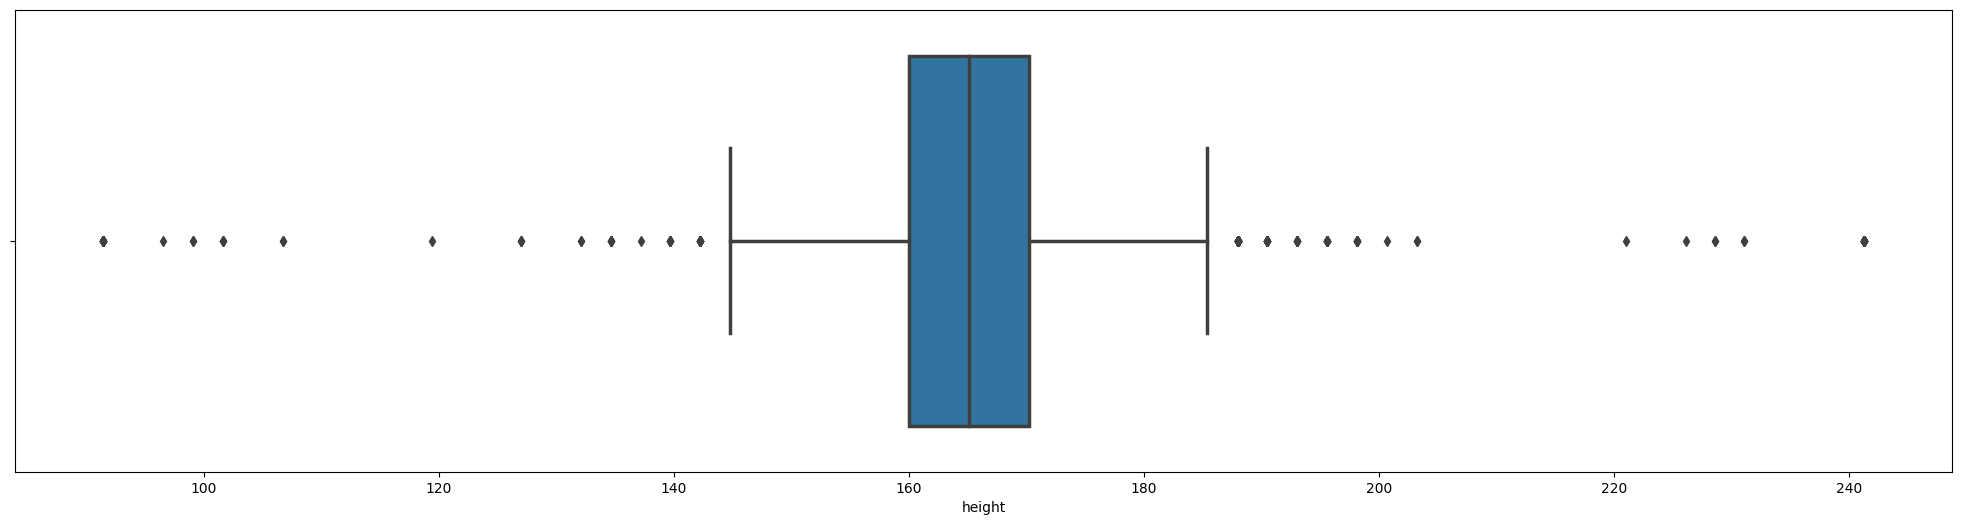

In [ ]:
def plot_outlier(feature):
  plt.figure(figsize=(25, 6))
  ax = sns.boxplot(x=feature, linewidth=2.5)
plot_outlier(df.height)

In [ ]:
# Mengambil hanya kolom numerik dari DataFrame Anda
numeric_columns = df.select_dtypes(include=['float64', 'int64'])

# Membuat korelasi antar kolom numerik
correlation_matrix = numeric_columns.corr()

# Membuat heatmap dari korelasi
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Antar Kolom Numerik")
plt.show()

In [ ]:
def get_outliers_range(datacolumn):
  sorted(datacolumn)
  Q1,Q3 = np.percentile(datacolumn , [25,75])
  IQR = Q3 - Q1
  lower_range = Q1 - (1.5 * IQR)
  upper_range = Q3 + (1.5 * IQR)
  return lower_range,upper_range

In [ ]:
ht_lower_range,ht_upper_range = get_outliers_range(df.height)
ht_lower_range,ht_upper_range

(144.70000000000002, 185.49999999999997)

In [ ]:
df[(df.height < ht_lower_range) | (df.height > ht_upper_range)]

,item_id,waist,mc_size,quality,cup_size,hips,bra_size,category,bust,height,user_name,length,fit,user_id,shoe_size,shoe_width,review_summary,review_test
468,125442,NaN,5,5.0,c,35.0,34.0,new,NaN,101.6,sarah.d.charleton,just right,fit,536627,NaN,NaN,NaN,NaN
1895,129268,NaN,20,3.0,NaN,NaN,NaN,new,NaN,190.5,fran4252,slightly short,small,768980,NaN,NaN,NaN,NaN
1952,129268,NaN,26,5.0,d,49.0,40.0,new,45,188.0,folkloregray,slightly long,fit,463032,10.5,average,NaN,NaN
2919,136482,NaN,32,4.0,ddd/f,46.0,40.0,new,NaN,188.0,krobinson2011,just right,fit,372482,NaN,NaN,NaN,NaN
3223,137865,NaN,26,4.0,h,47.0,36.0,new,NaN,188.0,Leila,just right,fit,527524,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80344,792842,NaN,12,4.0,k,60.0,48.0,outerwear,NaN,241.3,bandnerd2522,just right,small,810539,11.5,average,I need blazers to wear ov,I need blazers to wear over some of my dresses...
80713,796383,NaN,12,4.0,k,60.0,48.0,outerwear,NaN,241.3,bandnerd2522,just right,small,810539,11.5,average,"This jacket is lovely, bu","This jacket is lovely, but I couldn't move my ..."
81083,803464,NaN,4,5.0,NaN,NaN,NaN,outerwear,NaN,241.3,Ida,just right,fit,887787,NaN,NaN,Finally a blazer that fit,Finally a blazer that fits me perfectly and do...
81846,806479,NaN,15,5.0,c,40.0,34.0,outerwear,NaN,188.0,brittanna75,slightly long,large,910471,9.5,average,I am very happy with this,I am very happy with this coat. It will be a ...


In [ ]:
df1 = df.drop(df[(df.height < ht_lower_range) | (df.height > ht_upper_range)].index)

df1.reset_index(drop=True, inplace=True)
df1.shape

(82591, 18)

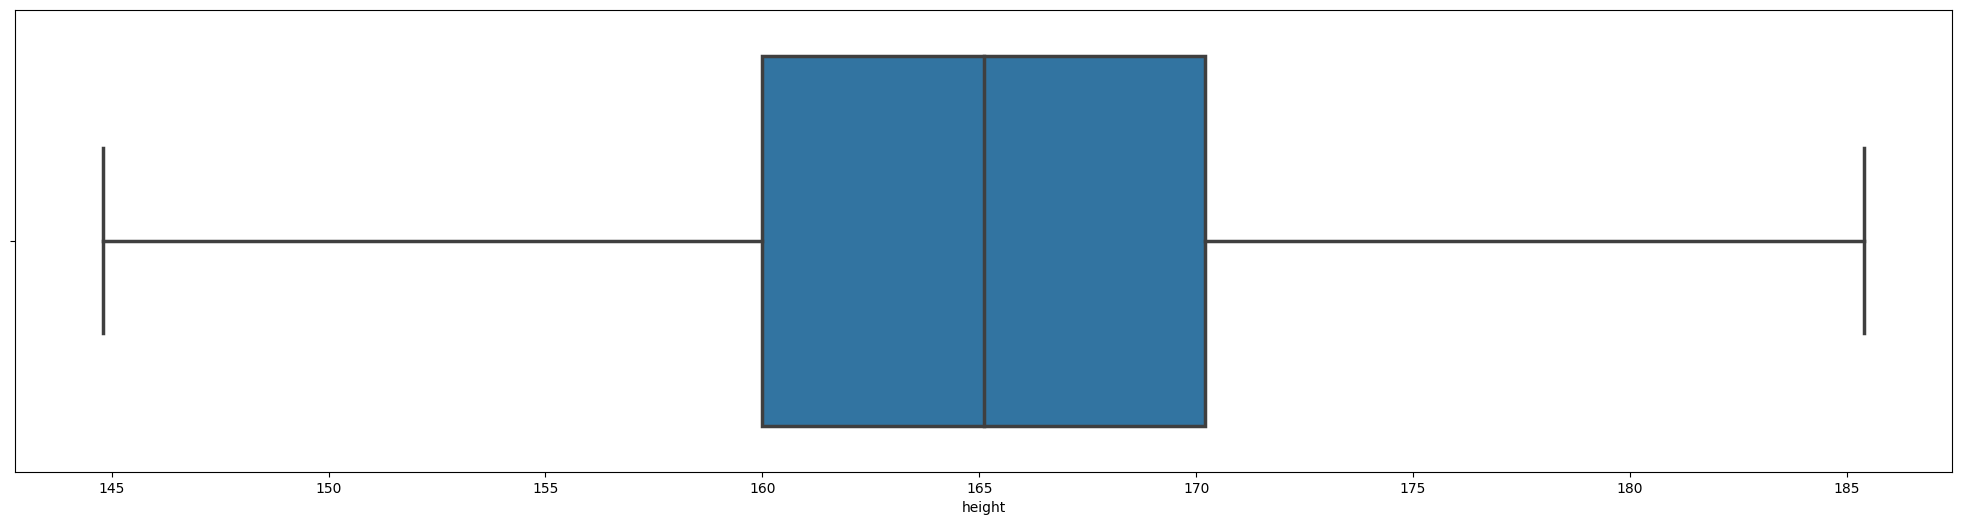

In [ ]:
plot_outlier(df1.height)

In [ ]:
def plot_dist(df, indipendent_features):
  plt.figure(figsize=(25, 20))
  for loc, feature in enumerate(indipendent_features):
    ax = plt.subplot(3, 3, loc+1)
    sns.distplot(df[feature]) # you can try histplot as well
  return None

<ipython-input-33-3436e377f651>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[feature]) # you can try histplot as well
<ipython-input-33-3436e377f651>:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[feature]) # you can try histplot as well
<ipython-input-33-3436e377f651>:5: UserWarning

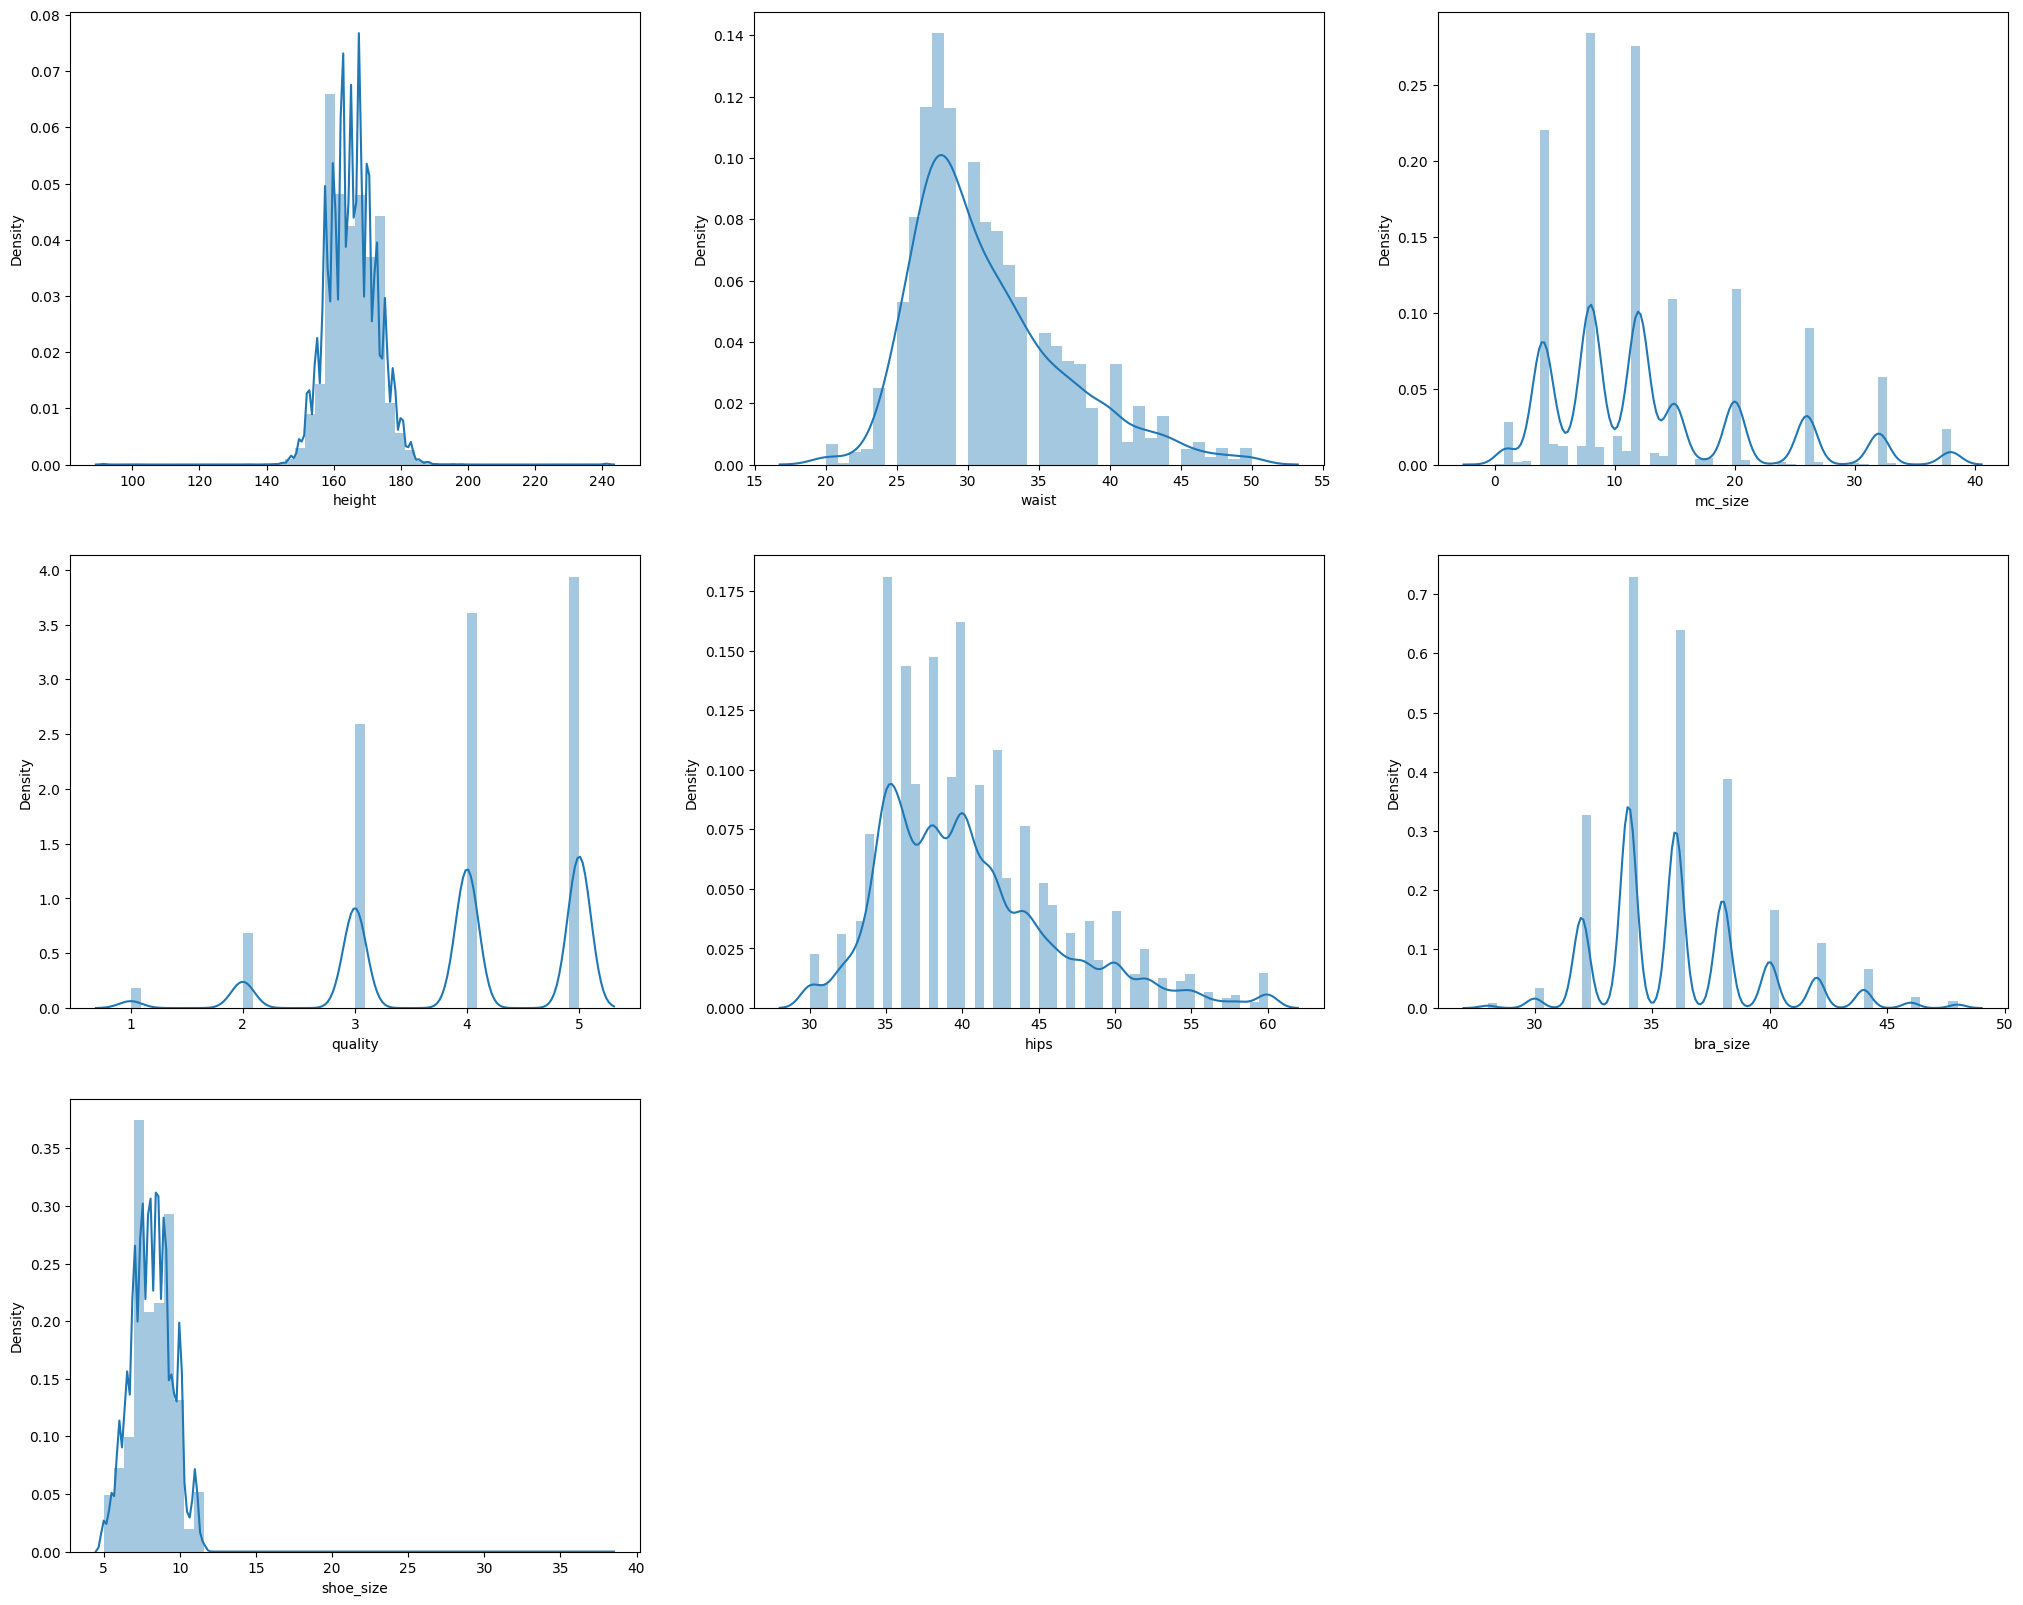

In [ ]:
plot_dist(df, ['height', 'waist', 'mc_size', 'quality', 'hips', 'bra_size', 'shoe_size'])

In [ ]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=10)

# finding imputation using other features (it will take couple of minutes to complete the execution)
mc_data_knn_ind_features = df1[['waist', 'hips', 'bra_size', 'bust', 'height', 'shoe_size']]

df2 = imputer.fit_transform(mc_data_knn_ind_features)


knn_numeric_imputations = pd.DataFrame(data=df2, columns=['waist', 'hips', 'bra_size', 'bust', 'height', 'shoe_size'])


# remove the existing numeric columns (waist, height, hips, bra_size, bust, shoe_size ) from the main dataframe and concatenate  with knn imputed data
#df1 = mc_data
mc_new_df = df1.drop(['waist', 'hips', 'bra_size', 'bust', 'height', 'shoe_size'], axis=1)

In [ ]:
df3 = pd.concat([mc_new_df, knn_numeric_imputations], axis=1)
df3.isnull().sum()

item_id               0
mc_size               0
quality              68
cup_size           6231
category              0
user_name             0
length               35
fit                   0
user_id               0
shoe_width        64023
review_summary     6710
review_test        6710
waist                 0
hips                  0
bra_size              0
bust                  0
height                0
shoe_size             0
dtype: int64

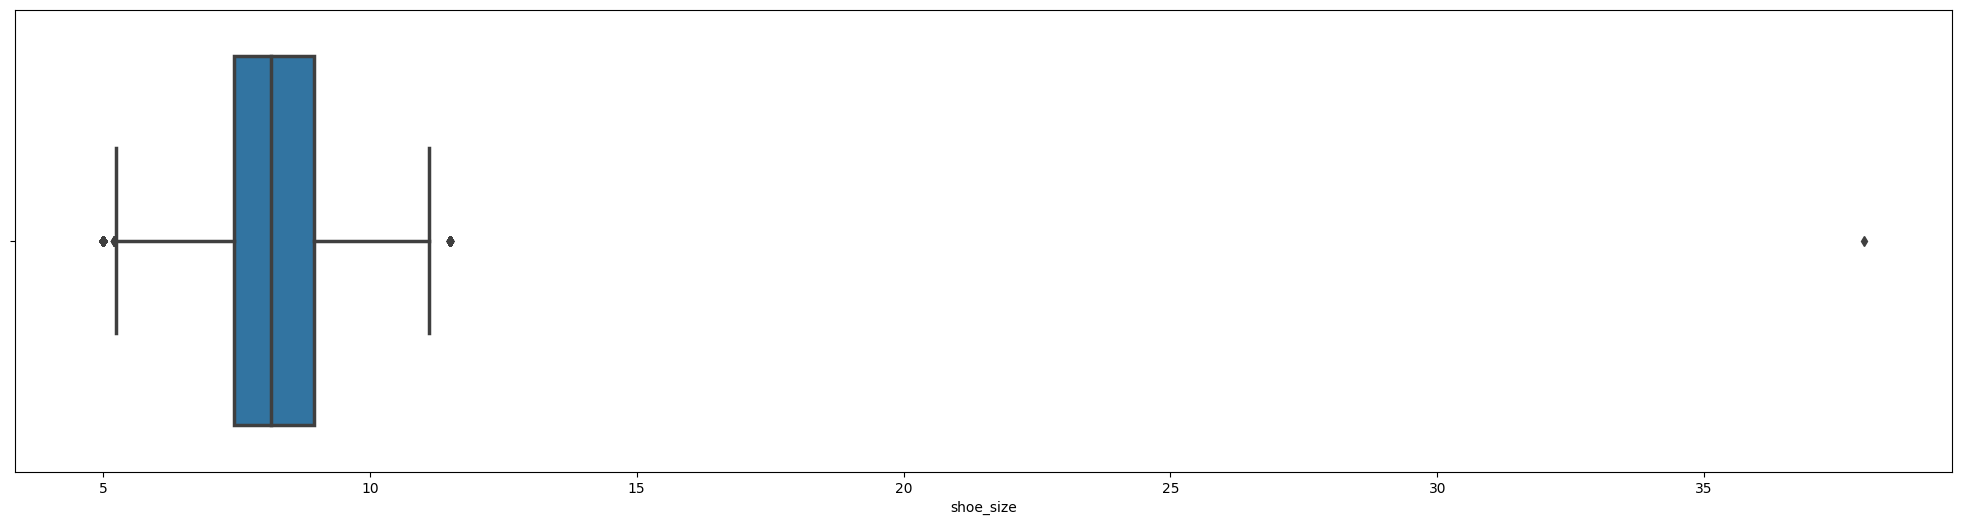

In [ ]:
plot_outlier(df3.shoe_size)

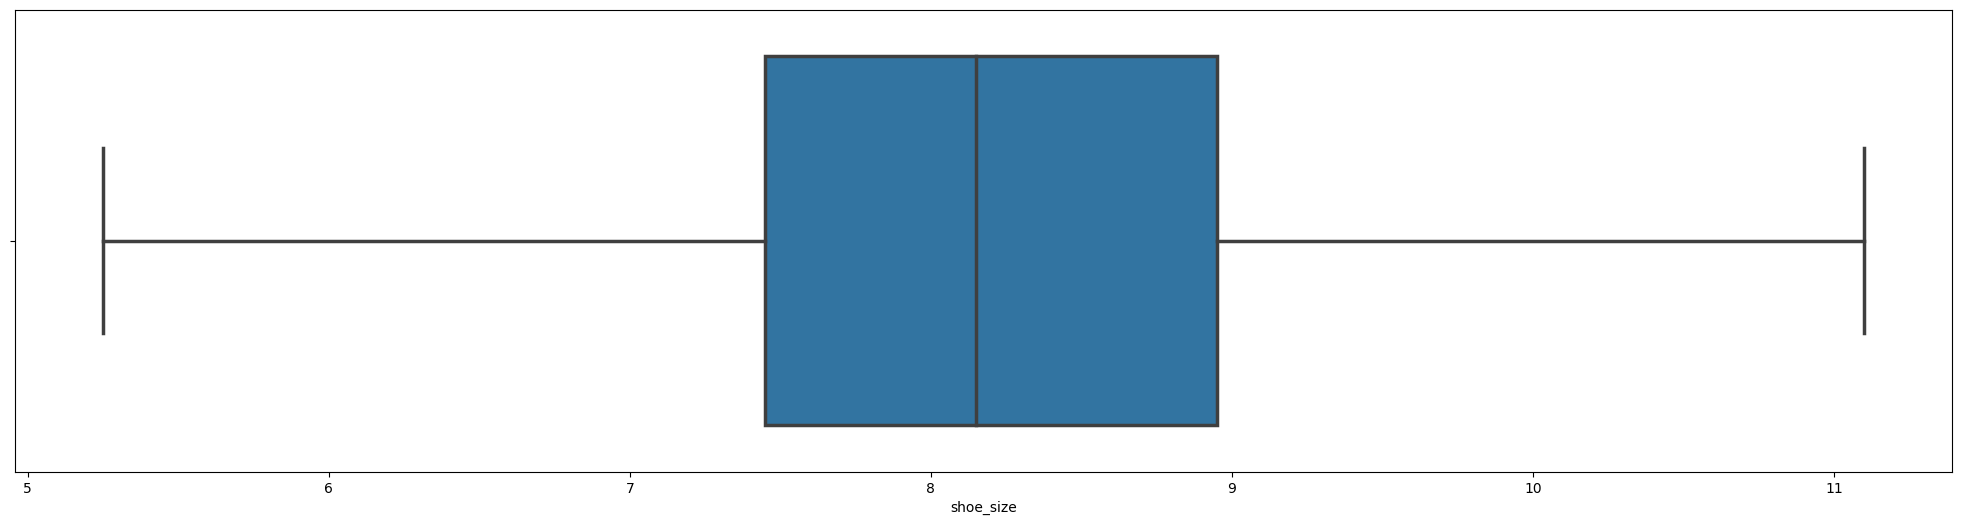

In [ ]:
ss_lower_range,ss_upper_range = get_outliers_range(df3.shoe_size)
#print(ss_lower_range,ss_upper_range)

df3.drop(df3[(df3.shoe_size < ss_lower_range) | (df3.shoe_size > ss_upper_range)].index, axis=0, inplace=True) # found 390 observations
plot_outlier(df3.shoe_size)

In [ ]:
def convert_cup_size_to_cms(cup_size_code):
  if cup_size_code == 'aa':
    return 10, 11
  if cup_size_code == 'a':
    return 12, 13
  if cup_size_code == 'b':
    return 14, 15
  if cup_size_code == 'c':
    return 16, 17
  if cup_size_code == 'd':
    return 18, 19
  if cup_size_code == 'dd/e':
    return 20, 21
  if cup_size_code == 'ddd/f':
    return 22, 23
  if cup_size_code == 'dddd/g':
    return 24, 25
  if cup_size_code == 'h':
    return 26, 27
  if cup_size_code == 'i':
    return 28, 29
  if cup_size_code == 'j':
    return 30, 31
  if cup_size_code == 'k':
    return 32, 33
  else:
    return str('unknown')

In [ ]:
df3['cup_size_in_cms'] = df3.cup_size.apply(convert_cup_size_to_cms)
df3.head()

,item_id,mc_size,quality,cup_size,category,user_name,length,fit,user_id,shoe_width,review_summary,review_test,waist,hips,bra_size,bust,height,shoe_size,cup_size_in_cms
0,123373,7,5.0,d,new,Emily,just right,small,991571,NaN,NaN,NaN,29.0,38.0,34.0,36.0,167.600000,7.75,"(18, 19)"
1,123373,13,3.0,b,new,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,31.0,30.0,36.0,37.8,157.500000,7.25,"(14, 15)"
2,123373,7,2.0,b,new,Ugggh,slightly long,small,395665,NaN,NaN,NaN,30.0,35.9,32.0,32.9,170.200000,9.00,"(14, 15)"
3,123373,21,5.0,dd/e,new,alexmeyer626,just right,fit,875643,NaN,NaN,NaN,30.4,41.7,38.6,40.3,165.472612,8.40,"(20, 21)"
4,123373,18,5.0,b,new,dberrones1,slightly long,small,944840,NaN,NaN,NaN,31.1,39.2,36.0,37.4,157.500000,7.40,"(14, 15)"


In [ ]:
def split_cup_size_data(data, index):
  if data.lower() == 'unknown':
    return 0
  value = data.replace('(','').replace(')','').replace(',','')
  return value.split()[index]

df3['cup_size_start_in_cms'] =  df3.cup_size_in_cms.astype(str).apply(lambda x : split_cup_size_data(x, 0))
df3['cup_size_end_in_cms'] =  df3.cup_size_in_cms.astype(str).apply(lambda x : split_cup_size_data(x, 1))
df3.head()

,item_id,mc_size,quality,cup_size,category,user_name,length,fit,user_id,shoe_width,...,review_test,waist,hips,bra_size,bust,height,shoe_size,cup_size_in_cms,cup_size_start_in_cms,cup_size_end_in_cms
0,123373,7,5.0,d,new,Emily,just right,small,991571,NaN,...,NaN,29.0,38.0,34.0,36.0,167.600000,7.75,"(18, 19)",18,19
1,123373,13,3.0,b,new,sydneybraden2001,just right,small,587883,NaN,...,NaN,31.0,30.0,36.0,37.8,157.500000,7.25,"(14, 15)",14,15
2,123373,7,2.0,b,new,Ugggh,slightly long,small,395665,NaN,...,NaN,30.0,35.9,32.0,32.9,170.200000,9.00,"(14, 15)",14,15
3,123373,21,5.0,dd/e,new,alexmeyer626,just right,fit,875643,NaN,...,NaN,30.4,41.7,38.6,40.3,165.472612,8.40,"(20, 21)",20,21
4,123373,18,5.0,b,new,dberrones1,slightly long,small,944840,NaN,...,NaN,31.1,39.2,36.0,37.4,157.500000,7.40,"(14, 15)",14,15


In [ ]:
df3['cup_size_start_in_cms'] = df3.cup_size_start_in_cms.astype('int')
df3['cup_size_end_in_cms'] = df3.cup_size_end_in_cms.astype('int')


# missing values imputation with mean
df3['cup_size_start_in_cms']  = df3.cup_size_start_in_cms.mask(df3.cup_size_start_in_cms==0).fillna(value=df3.cup_size_start_in_cms.mean())
df3['cup_size_end_in_cms']  = df3.cup_size_end_in_cms.mask(df3.cup_size_end_in_cms==0).fillna(value=df3.cup_size_end_in_cms.mean())

In [ ]:
df3[df3.cup_size.isnull()]

,item_id,mc_size,quality,cup_size,category,user_name,length,fit,user_id,shoe_width,...,review_test,waist,hips,bra_size,bust,height,shoe_size,cup_size_in_cms,cup_size_start_in_cms,cup_size_end_in_cms
61,124024,9,5.0,NaN,new,cdpase,just right,fit,277450,NaN,...,NaN,30.0,37.7,34.4,36.8,160.0,7.20,unknown,16.041532,16.965888
70,124124,26,5.0,NaN,new,inevitable.cities,slightly long,fit,29730,NaN,...,NaN,34.2,40.0,37.6,35.4,175.3,10.10,unknown,16.041532,16.965888
72,124124,26,3.0,NaN,new,Josephine,slightly short,fit,497767,NaN,...,NaN,34.2,40.0,37.6,35.4,175.3,10.10,unknown,16.041532,16.965888
99,124124,12,1.0,NaN,new,christine.koch,very short,small,435872,NaN,...,NaN,32.7,46.5,35.2,38.0,170.2,8.80,unknown,16.041532,16.965888
101,124124,15,4.0,NaN,new,meghanmurphy,just right,small,788667,NaN,...,NaN,31.0,39.8,34.4,36.0,157.5,6.90,unknown,16.041532,16.965888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82525,807384,8,3.0,NaN,outerwear,streamlineblue,just right,fit,336703,NaN,...,This coat is awesome! Fit/length/color/style i...,30.6,38.5,35.6,35.7,162.6,7.85,unknown,16.041532,16.965888
82562,807722,4,5.0,NaN,outerwear,melissalehtonen,just right,fit,357068,NaN,...,Love it!!!!! P,31.0,39.8,34.4,36.0,157.5,6.90,unknown,16.041532,16.965888
82565,807722,4,5.0,NaN,outerwear,Hufsa,just right,fit,475911,NaN,...,Perfect for work dresses.,30.0,37.7,34.4,36.8,160.0,7.20,unknown,16.041532,16.965888
82578,807722,8,4.0,NaN,outerwear,spoons_82,just right,small,236365,NaN,...,Had to return I'm usually a medium in shirts ...,29.3,38.0,34.0,37.7,162.6,7.80,unknown,16.041532,16.965888


In [ ]:
# drop the columns which are used for reference
mc = mc.drop(['cup_size', 'cup_size_in_cms'], axis = 1)
mc.reset_index(drop=True,  inplace=True)